
## Prediction uncertainty and calibration

In this exercise, we compare 3 

1. Random Forest (variance across trees): epistemic proxy
2. Quantile Random Forest (empirical intervals) – distribution-free intervals
3. Gaussian Process regression: Bayesian predictive uncertainty


Imports

In [1]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import r2_score, root_mean_squared_error

from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

ImportError: cannot import name 'root_mean_squared_error' from 'sklearn.metrics' (/Users/raphaeland./opt/anaconda3/envs/DAC_env/lib/python3.8/site-packages/sklearn/metrics/__init__.py)

### 1. Load ESOL Dataset 
from session 11

In [2]:
df = pd.read_csv(os.path.join("..", "..", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])

### 2. Calculate fingerprints and split data
In this example, we use MACCS. Feel free to calculate Morgan fingerprints, RDKit descriptors, or any other structural encoding of your choice.

In [3]:
from utils import maccs_fp_from_smiles # import function from utils

smiles = df['SMILES'].values # Structures (SMILES)
y = df['LogP'].values # Target variable

X, idx = maccs_fp_from_smiles(smiles) # Calculate fingerprints (MACCS)

# create dataframe
all_esol_df = pd.DataFrame({'SMILES': df['SMILES'], 
                           'LogP': df['LogP'],
                           })

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=42)



### 3. Random Forest: Epistemic uncertainty proxies


In [14]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# i) Mean and variance across trees
rf_tree_predictions = np.array([t.predict(X_test) for t in rf.estimators_]) # estimators are the individual trees in the forest
rf_mean = rf_tree_predictions.mean(axis=0)
rf_std = rf_tree_predictions.std(axis=0)

# ii) Quantiles from trees
# from the distribution of trees, we can further calculate quantiles
q_low, q_high = 0.1, 0.9 # 10% and 90% quantiles aka 80% confidence interval
qrf_lower = np.quantile(rf_tree_predictions, q_low, axis=0)
qrf_upper = np.quantile(rf_tree_predictions, q_high, axis=0)
qrf_mean = rf_mean

# Check overall model performance on test set
print('Test R²:', r2_score(y_test, rf_mean))
print('Test RMSE:', root_mean_squared_error(y_test, rf_mean))

Test R²: 0.818269699967846
Test RMSE: 0.8195319168771223



### 4. Gaussian Process Regression

We reduce dimensionality using PCA for numerical stability.
GP provides a posterior predictive uncertainty.


In [15]:
pca = PCA(n_components=20, random_state=42) # addvised to use PCA for dimensionality reduction before applying Gaussian Process Regression, as GPR can be computationally expensive with high-dimensional data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

kernel = RBF(length_scale=1.0) + WhiteKernel() # to improve model performance, the kernel can be optimized
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
gp.fit(X_train_pca, y_train)

gp_mean, gp_std = gp.predict(X_test_pca, return_std=True) # important: return standard deviation of the prediction

# Check overall model performance on test set
print('Test R²:', r2_score(y_test, gp_mean))
print('Test RMSE:', root_mean_squared_error(y_test, gp_mean))

Test R²: 0.8103302476333938
Test RMSE: 0.8372424477731834


In [16]:
# collect results
df_test_pred = pd.DataFrame({
    "RF_mean": rf_mean,
    "RF_std": rf_std,
    "GP_mean": gp_mean, 
    "GP_std": gp_std,
    "RF_upper_quantile": qrf_upper,
    "RF_lower_quantile": qrf_lower,
    "LogP": y_test,
    })

### 5. Uncertainty calibration
Let's look at the RF quantiles first

In [17]:
# Quantile RF (fixed interval)
below = (y_test >= qrf_lower) # true logP is above the lower prediction threshold
above = (y_test <= qrf_upper) # true logP is below the upper prediction threshold
# count how many times the true value is both above qrf_lower and below qrf_lower
# --> WITHIN the confidence interval
emp_cov_qrf = np.mean(below & above)
print('Empirical coverage of Quantile RF (10–90%)', emp_cov_qrf)

Empirical coverage of Quantile RF (10–90%) 0.7566371681415929


What would be the ideal value for the empirical coverage here?
Is the Quantile RF overconfident or underconfident? --> its overconfident its 75% idealy it should be 80%

Next, let's look at different confidence levels (or, levels of "nominal coverage")

In [10]:
confidence = np.linspace(0.1, 0.9, 9) # confidence levels: 10%, 20%, ... , 90%

df_calibration = pd.DataFrame()

for method in ["RF", "GP"]:
    df_cal = pd.DataFrame()
    df_cal['Nominal coverage'] = confidence
    coverage = []
    for c in confidence:
        z = norm.ppf(0.5 + c / 2) # z: multiplication factor for the standard deviation to obtain confidence interval limits
        # predictions below the lower confidence threshold mu-(z*std):
        above = (df_test_pred["LogP"] >= df_test_pred[f"{method}_mean"] - z*df_test_pred[f"{method}_std"]) 
        # predictions above the upper confidence threshold mu+(z*std):
        below = (df_test_pred["LogP"] <= df_test_pred[f"{method}_mean"] + z*df_test_pred[f"{method}_std"])
        coverage.append(np.mean(below & above))
    df_cal['Empirical coverage'] = coverage
    df_cal['Method'] = [method]*9
    
    df_calibration = pd.concat([df_calibration, df_cal])

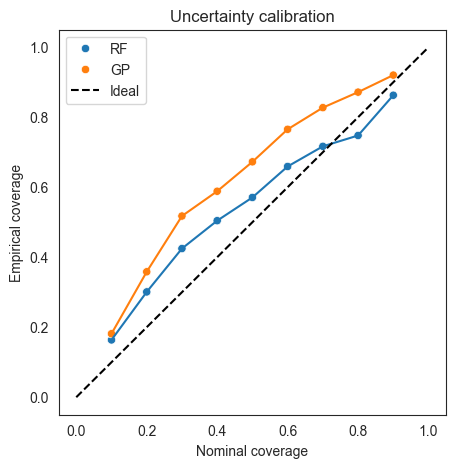

ECE RF: 0.07000983284169124
ECE GP: 0.13372664700098327


In [11]:
# Plot calibration curve
sns.set_style("white")
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df_calibration, x='Nominal coverage', y='Empirical coverage', hue='Method', markers='o')
sns.lineplot(data=df_calibration, x='Nominal coverage', y='Empirical coverage', hue='Method', markers='o', legend=False)

plt.plot([0,1],[0,1],'--',label='Ideal', color='black')

plt.title("Uncertainty calibration")
plt.legend()
plt.show()

# calculate the Expected Calibration Error (ECE)
# ECE = 0: perfect calibration
# ECE > 0 : The smaller the ECE, the better the calibration
for method in ["RF", "GP"]:
    ece = np.mean(np.abs(df_calibration[df_calibration['Method']==method]['Empirical coverage'] -  df_calibration[df_calibration['Method']==method]['Nominal coverage']))
    print(f"ECE {method}: {ece}")
    

the closder to 0 the better it is for ECE

### 6. Predict uncertainties for test substances

In [19]:
# load external test molecules
external_test_molecules = {
    'Estradiol (hormone)': 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3C=CC(=C4)O',
    
    'PFOA (PFAS)': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O',
    
    'Bisphenol A (endocrine disruptor)': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
    
    'Copper sulfate (metal salt)': '[O-]S(=O)(=O)[O-].[Cu+2]',
    
    'Fullerene (nanomaterial)' : 'C12=C3C4=C5C6=C1C7=C8C9=C1C%10=C%11C(=C29)C3=C2C3=C4C4=C5C5=C9C6=C7C6=C7C8=C1C1=C8C%10=C%10C%11=C2C2=C3C3=C4C4=C5C5=C%11C%12=C(C6=C95)C7=C1C1=C%12C5=C%11C4=C3C3=C5C(=C81)C%10=C23',
    
    'Erythromycin (antibiotic)': 'CC[C@@H]1[C@@]([C@@H]([C@H](C(=O)[C@@H](C[C@@]([C@@H]([C@H]([C@@H]([C@H](C(=O)O1)C)O[C@H]2C[C@@]([C@H]([C@@H](O2)C)O)(C)OC)C)O[C@H]3[C@@H]([C@H](C[C@H](O3)C)N(C)C)O)(C)O)C)C)O)(C)O',
    
    'Chlorophyll B (pigment)': 'CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@H](C(=N5)C=C6C(=C(C(=C2)[N-]6)C=C)C)C)CCC(=O)OC/C=C(\C)/CCC[C@H](C)CCC[C@H](C)CCCC(C)C)[C@H](C4=O)C(=O)OC)C)C=O.[Mg+2]',
    
    'DNA (polymer)' : 'CC1=CN(C(=O)NC1=O)C2CC(C(O2)COP(=S)(O)OC3CC(OC3COP(=S)(O)OC4CC(OC4COP(=S)(O)OC5CC(OC5COP(=S)(O)OC6CC(OC6COP(=S)(O)OC7CC(OC7COP(=S)(O)OC8CC(OC8COP(=S)(O)OC9CC(OC9COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1CO)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=NC2=C1N=C(NC2=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)O',
}
test_ext_df = pd.DataFrame()
test_ext_df['Name'] = external_test_molecules.keys()
test_ext_df['SMILES'] = external_test_molecules.values()
template_df = test_ext_df.copy() # as a template for data collection


In [61]:
X_test_ext, _ = maccs_fp_from_smiles(test_ext_df['SMILES'].values)
# RF
rf_tree_predictions = np.array([t.predict(X_test_ext) for t in rf.estimators_])
rf_mean = rf_tree_predictions.mean(axis=0)
rf_std = rf_tree_predictions.std(axis=0)
rf_median = np.median(rf_tree_predictions, axis=0)
qrf_lower = np.quantile(rf_tree_predictions, q_low, axis=0)
qrf_upper = np.quantile(rf_tree_predictions, q_high, axis=0)
# Add results to data frame
test_ext_df['LogP_RF_mean'] = rf_mean
test_ext_df['LogP_RF_median'] = rf_median
test_ext_df['LogP_RF_std'] = rf_std
test_ext_df['LogP_RF_lower'] = qrf_lower
test_ext_df['LogP_RF_upper'] = qrf_upper

# GP
pred_ext_GP_mean, pred_ext_GP_std = gp.predict(pca.transform(X_test_ext), return_std=True) # predict logP

# Add results to data frame
test_ext_df['LogP_GP_mean'] = pred_ext_GP_mean
test_ext_df['LogP_GP_std'] = pred_ext_GP_std

print('\n*** LogP predictions ***\n')
print(test_ext_df.drop(columns=['SMILES']))


*** LogP predictions ***

                                Name  LogP_RF_mean  LogP_RF_std  LogP_GP_mean  \
0                Estradiol (hormone)      3.558824     0.456146      3.736326   
1                        PFOA (PFAS)      2.519592     0.599327      1.063633   
2  Bisphenol A (endocrine disruptor)      4.073062     1.071033      4.140165   
3        Copper sulfate (metal salt)      0.622078     0.955460      1.930081   
4           Fullerene (nanomaterial)      4.522172     0.629606      4.154510   
5          Erythromycin (antibiotic)      1.701820     2.109969      0.884082   
6            Chlorophyll B (pigment)      5.149656     1.506661      3.757201   
7                      DNA (polymer)      1.614743     1.327731      0.431025   

   LogP_GP_std  LogP_RF_lower  LogP_RF_upper  LogP_RF_median  
0     0.782622       3.600042        3.61260         3.60920  
1     0.794928       1.809340        2.91890         2.70540  
2     0.814829       2.736360        5.26898         3

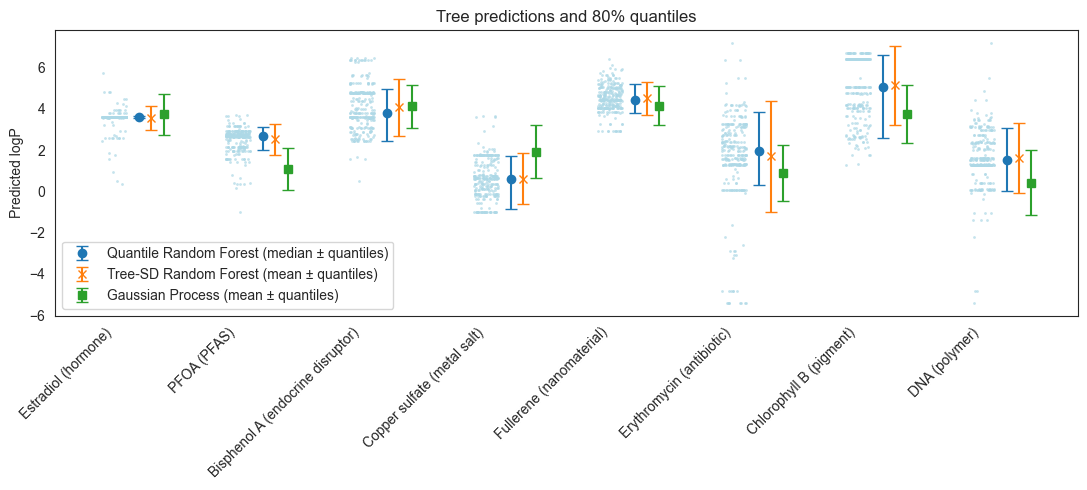

In [66]:
# Assume df is your DataFrame
x = np.arange(len(test_ext_df))

# Asymmetric RF errors (must be positive)
rf_yquant_lower = abs(test_ext_df["LogP_RF_mean"] - test_ext_df["LogP_RF_lower"])
rf_yquant_upper = abs(test_ext_df["LogP_RF_upper"] - test_ext_df["LogP_RF_mean"])

# 80% quantile using std assuming normal distribution
z = norm.ppf(0.9)  # Percent point function at 0.9: 1.2816 
quantile_RF_80 = z  * test_ext_df["LogP_RF_std"]
quantile_GP_80 = z  * test_ext_df["LogP_GP_std"]


plt.figure(figsize=(11, 5))
# plot single tree predictions
df_tree = pd.DataFrame(rf_tree_predictions)
sns.stripplot(df_tree, alpha=0.7, color='lightblue', size=2 )

# RF mean with quantile intervals
plt.errorbar(
    x+0.2,
    test_ext_df["LogP_RF_median"],
    yerr=[rf_yquant_lower, rf_yquant_upper],
    fmt="o",
    capsize=4,
    label="Quantile Random Forest (median ± quantiles)",
)

# RF mean with normally distributed 
plt.errorbar(
    x+0.3,
    test_ext_df["LogP_RF_mean"],
    yerr=[quantile_RF_80, quantile_RF_80],
    fmt="x",
    capsize=4,
    label="Tree-SD Random Forest (mean ± quantiles)",
)

# GP mean (no intervals, just means)
plt.errorbar(
    x + 0.4,
    test_ext_df["LogP_GP_mean"],
    yerr=[quantile_GP_80, quantile_GP_80],
    fmt="s",
    capsize=4,
    label="Gaussian Process (mean ± quantiles)",
)

plt.xticks(x, test_ext_df["Name"], rotation=45, ha="right")
plt.ylabel("Predicted logP")
plt.title("Tree predictions and 80% quantiles")
plt.legend()
plt.tight_layout()
plt.show()


Tree-SD is just the RF with the SD include in it 


### Questions

- Which model is better calibrated?
- Which predictions for our test substances would you trust?

